## Cat Video and OpenCV Feature Tracking

### Cat Video Placeholder

I can't directly provide a cat video, but you can embed one using `IPython.display.Video` by replacing the placeholder URL with your desired video link.

In [ ]:
from IPython.display import Video

# To display a cat video that moves for about 30 seconds:
# 1. Find a suitable cat video online (e.g., on YouTube or a direct video link to an .mp4 file).
# 2. Replace the 'cat_video_url' below with the actual URL of your chosen video.
#    For YouTube videos, sometimes using the direct embed URL or a converter is needed for direct display.
#    Example for a direct MP4 link:
#    cat_video_url = "https://www.example.com/your_cat_video.mp4"
#    Example for an embeddable YouTube link (often requires more specific handling or a different library):
#    cat_video_url = "https://www.youtube.com/embed/YOUR_VIDEO_ID?autoplay=1"

# Placeholder URL (This is a generic sample MP4, you will likely want to replace it)
cat_video_url = "https://www.youtube.com/watch?v=XVO9CS8D4hQ" # This is a sample video, replace with a cat video!

# Display the video
Video(cat_video_url, width=600, height=300)

### OpenCV `goodFeaturesToTrack` Demonstration

Below is an example of how to use `cv2.goodFeaturesToTrack` to find prominent corners in an image. I'll create a dummy image for demonstration purposes.

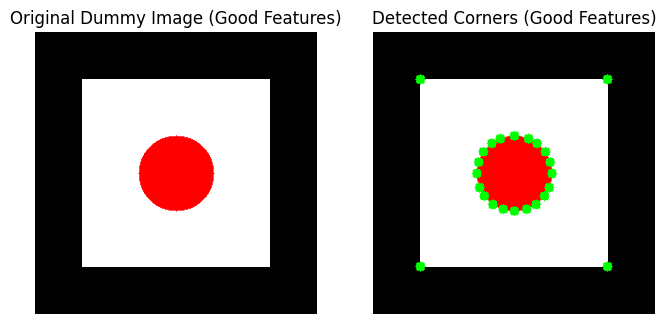

Detected 24 corners in static image.

--- Demonstrando Flujo Óptico de Lucas-Kanade para Seguimiento de Video ---
Se procesaron 100 cuadros para el seguimiento.


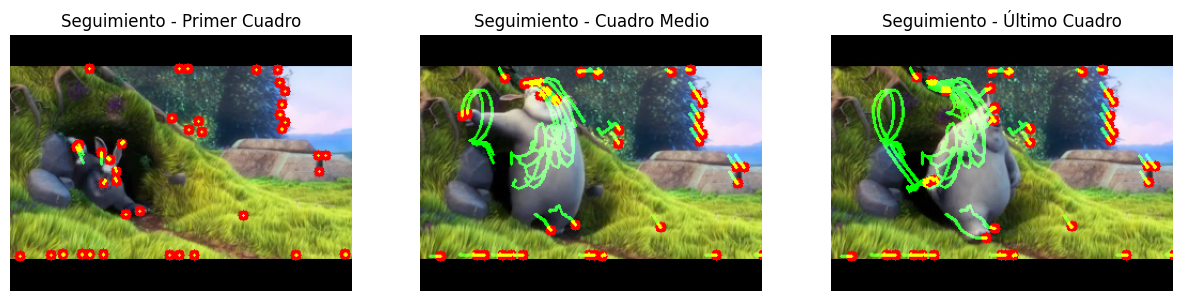

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, HTML, display

# --- Part 1: goodFeaturesToTrack Demonstration on a Static Image (as before) ---
# Create a dummy image for demonstration
img = np.zeros((300, 300, 3), dtype=np.uint8)
img[50:250, 50:250] = [255, 255, 255] # White square
img = cv2.circle(img, (150, 150), 40, (0, 0, 255), -1) # Add a red circle in the center

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Parameters for goodFeaturesToTrack
max_corners = 100
quality_level = 0.01
min_distance = 10

# Detect corners
corners = cv2.goodFeaturesToTrack(gray, max_corners, quality_level, min_distance)
corners = corners.astype(int)

# Draw the detected corners
img_with_corners = img.copy()
for i in corners:
    x, y = i.ravel()
    cv2.circle(img_with_corners, (x, y), 5, (0, 255, 0), -1)

# Display the results
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Dummy Image (Good Features)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
plt.title('Detected Corners (Good Features)')
plt.axis('off')
plt.show()
print(f"Detected {len(corners)} corners in static image.")


# --- Part 2: Lucas-Kanade Optical Flow for Feature Tracking in Video ---
print("\n--- Demonstrando Flujo Óptico de Lucas-Kanade para Seguimiento de Video ---")

# Placeholder for a video URL that can be read by cv2.VideoCapture
# YouTube links generally do NOT work directly with cv2.VideoCapture.
# You would need to download the video first or use a direct MP4 link.
# For demonstration, let's use a generic, publicly available MP4 link.
# If you want to use the cat video, you would first need to download it
# and provide its local path or a direct MP4 URL.
# E.g., cap = cv2.VideoCapture('/content/your_downloaded_cat_video.mp4')
video_path_or_url = 'https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4'

cap = cv2.VideoCapture(video_path_or_url)

if not cap.isOpened():
    print(f"Error: No se pudo abrir la fuente de video en {video_path_or_url}. Asegúrate de que sea un enlace directo de video o un archivo local.")
else:
    # Read the first frame
    ret, old_frame = cap.read()
    if not ret:
        print("Error: No se pudo leer el primer cuadro.")
    else:
        old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
        # Find initial good features to track
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

        # Create a mask image for drawing purposes
        mask = np.zeros_like(old_frame)

        output_frames = []
        frame_count = 0
        max_frames = 100 # Limit frames for demonstration to avoid excessive processing

        while True:
            ret, frame = cap.read()
            if not ret or frame_count >= max_frames:
                break

            frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Calculate optical flow using Lucas-Kanade
            # p1: new points, st: status (1 if found, 0 if not), err: error
            p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None,
                                                    winSize=(15, 15), maxLevel=2,
                                                    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

            # Select good points
            if p1 is not None:
                good_new = p1[st == 1]
                good_old = p0[st == 1]

                # Draw the tracks
                for i, (new, old) in enumerate(zip(good_new, good_old)):
                    a, b = new.ravel().astype(int)
                    c, d = old.ravel().astype(int)
                    mask = cv2.line(mask, (a, b), (c, d), (0, 255, 0), 2)
                    frame = cv2.circle(frame, (a, b), 5, (0, 0, 255), -1)

                img_combined = cv2.add(frame, mask)
                # Convert to RGB for matplotlib/saving (if needed)
                output_frames.append(cv2.cvtColor(img_combined, cv2.COLOR_BGR2RGB))

                # Update the previous frame and previous points
                old_gray = frame_gray.copy()
                p0 = good_new.reshape(-1, 1, 2)
            else:
                # If no points are tracked, re-detect features in the current frame
                p0 = cv2.goodFeaturesToTrack(frame_gray, mask=None, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
                mask = np.zeros_like(frame) # Reset mask to avoid old tracks persisting if points are lost

            frame_count += 1

        cap.release()

        if output_frames:
            print(f"Se procesaron {len(output_frames)} cuadros para el seguimiento.")

            # Display a few frames to show the tracking result
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(output_frames[0])
            plt.title('Seguimiento - Primer Cuadro')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(output_frames[len(output_frames)//2])
            plt.title('Seguimiento - Cuadro Medio')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(output_frames[-1])
            plt.title('Seguimiento - Último Cuadro')
            plt.axis('off')
            plt.show()

        else:
            print("No se procesaron cuadros para el seguimiento. Verifique la fuente del video o la lectura de cuadros.")


--- Generando Video de Diferencia de Cuadros ---
Procesamiento limitado a 200 cuadros.
Se generó un video de diferencias de cuadros: delta_video.mp4 con 196 cuadros.
Mostrando los primeros 3 cuadros del video generado y luego se iniciará la descarga.


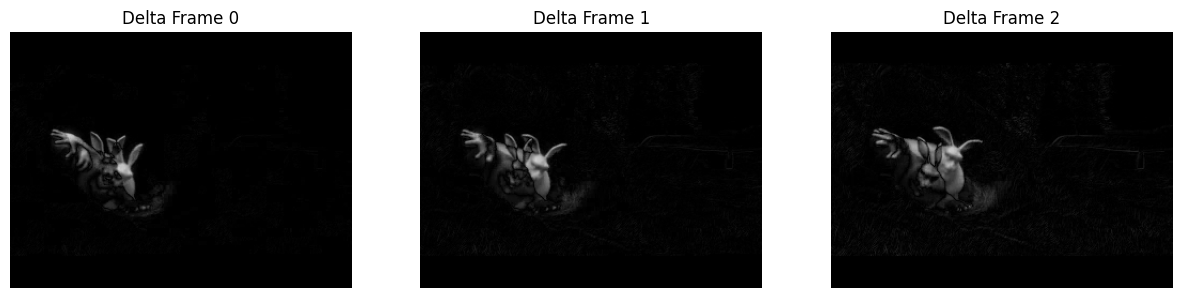

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from collections import deque
from IPython.display import Video, display # Remove FileLink from here
import matplotlib.pyplot as plt
from google.colab import files # Import files module for download

print("\n--- Generando Video de Diferencia de Cuadros ---")

# Reuse the video URL from the previous cell
# If you want to use a different video, update video_path_or_url here or in the previous cell.
# video_path_or_url = 'https://www.example.com/your_new_video.mp4'

cap = cv2.VideoCapture(video_path_or_url)

if not cap.isOpened():
    print(f"Error: No se pudo abrir la fuente de video en {video_path_or_url}. Asegúrate de que sea un enlace directo de video o un archivo local.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the frame interval for differencing (e.g., frame[i+delta] - frame[i])
    # User requested 'frame 1 minus frame 5', implying a delta of 4 frames.
    delta_frame_interval = 4

    # Buffer to hold frames for differencing
    frame_buffer = deque(maxlen=delta_frame_interval + 1)
    delta_frames_list = []

    output_filename = 'delta_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'MP4V') # Codec for MP4

    # VideoWriter setup: write 3-channel grayscale frames
    out = cv2.VideoWriter(output_filename, fourcc, fps, (width, height), isColor=True)

    frame_count = 0
    max_frames_to_process = 200 # Limit processing to avoid very long execution

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count >= max_frames_to_process:
            print(f"Procesamiento limitado a {max_frames_to_process} cuadros.")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_buffer.append(gray_frame)

        if len(frame_buffer) == delta_frame_interval + 1:
            # Calculate absolute difference between the current frame and the one 'delta_frame_interval' frames ago
            delta_frame = cv2.absdiff(frame_buffer[delta_frame_interval], frame_buffer[0])

            # Convert delta_frame to 3 channels to be written by VideoWriter (optional, for color output)
            # If you want to visualize differences more clearly, you can apply a colormap
            # For simplicity, let's just convert it to a 3-channel grayscale image.
            delta_frame_bgr = cv2.cvtColor(delta_frame, cv2.COLOR_GRAY2BGR)

            delta_frames_list.append(delta_frame_bgr)
            out.write(delta_frame_bgr)

        frame_count += 1

    cap.release()
    out.release()

    if delta_frames_list:
        print(f"Se generó un video de diferencias de cuadros: {output_filename} con {len(delta_frames_list)} cuadros.")
        print("Mostrando los primeros 3 cuadros del video generado y luego se iniciará la descarga.")

        # Display the first few delta frames as images
        plt.figure(figsize=(15, 5))
        for i in range(min(3, len(delta_frames_list))):
            plt.subplot(1, 3, i + 1)
            plt.imshow(cv2.cvtColor(delta_frames_list[i], cv2.COLOR_BGR2RGB)) # Convert back to RGB for matplotlib
            plt.title(f'Delta Frame {i}')
            plt.axis('off')
        plt.show()

        # Trigger download using google.colab.files
        files.download(output_filename)
    else:
        print("No se generaron cuadros de diferencia. Verifique la duración del video o el intervalo de delta.")



--- Generando Video Binario de Diferencia de Cuadros ---
Procesamiento limitado a 200 cuadros.
Se generó un video binario de diferencias de cuadros: binary_delta_video.mp4 con 196 cuadros.
Mostrando los primeros 3 cuadros del video generado y luego se iniciará la descarga.


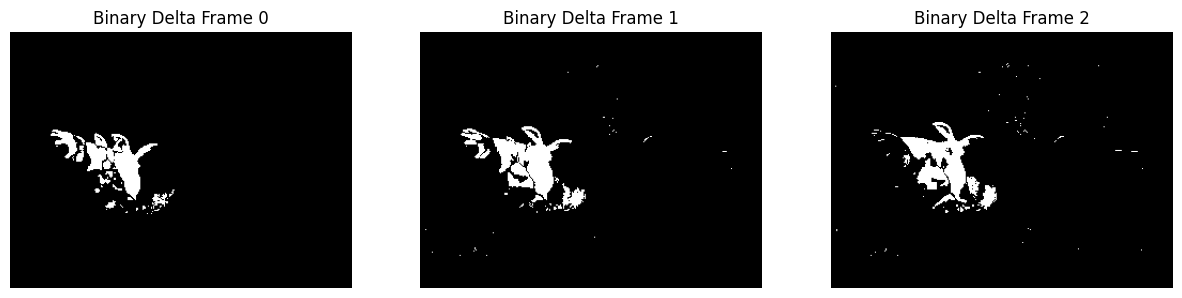

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import cv2
import numpy as np
from collections import deque
from IPython.display import Video, display
import matplotlib.pyplot as plt
from google.colab import files

print("\n--- Generando Video Binario de Diferencia de Cuadros ---")

# Reuse the video URL from the previous cell
# If you want to use a different video, update video_path_or_url here or in the previous cell.
# video_path_or_url = 'https://www.example.com/your_new_video.mp4'

cap = cv2.VideoCapture(video_path_or_url)

if not cap.isOpened():
    print(f"Error: No se pudo abrir la fuente de video en {video_path_or_url}. Asegúrate de que sea un enlace directo de video o un archivo local.")
elif video_path_or_url == 'https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4' and not cap.read()[0]:
    # Special handling for the sample URL if it fails, as it sometimes does in Colab environments.
    print("Warning: The default sample video URL might be unstable. Please consider providing a different direct MP4 link or downloading a video locally.")
    print(f"Error: No se pudo abrir la fuente de video en {video_path_or_url}. Asegúrate de que sea un enlace directo de video o un archivo local.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the frame interval for differencing (e.g., frame[i+delta] - frame[i])
    delta_frame_interval = 4 # This 'j' corresponds to the number of frames back for comparison

    # Define the threshold 'd' for binarization
    _THRESHOLD = 30 # You can adjust this value (0-255)

    # Buffer to hold frames for differencing
    frame_buffer = deque(maxlen=delta_frame_interval + 1)
    binary_delta_frames_list = []

    output_filename = 'binary_delta_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'MP4V') # Codec for MP4

    # VideoWriter setup: write 3-channel grayscale frames
    out = cv2.VideoWriter(output_filename, fourcc, fps, (width, height), isColor=True)

    frame_count = 0
    max_frames_to_process = 200 # Limit processing to avoid very long execution

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count >= max_frames_to_process:
            print(f"Procesamiento limitado a {max_frames_to_process} cuadros.")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_buffer.append(gray_frame)

        if len(frame_buffer) == delta_frame_interval + 1:
            # Calculate absolute difference between the current frame and the one 'delta_frame_interval' frames ago
            delta_frame = cv2.absdiff(frame_buffer[delta_frame_interval], frame_buffer[0])

            # Apply threshold to create a binary image: f(i) - f(i-j) > d ? 255 : 0
            _, binary_delta_frame = cv2.threshold(delta_frame, _THRESHOLD, 255, cv2.THRESH_BINARY)

            # Convert binary_delta_frame to 3 channels to be written by VideoWriter
            binary_delta_frame_bgr = cv2.cvtColor(binary_delta_frame, cv2.COLOR_GRAY2BGR)

            binary_delta_frames_list.append(binary_delta_frame_bgr)
            out.write(binary_delta_frame_bgr)

        frame_count += 1

    cap.release()
    out.release()

    if binary_delta_frames_list:
        print(f"Se generó un video binario de diferencias de cuadros: {output_filename} con {len(binary_delta_frames_list)} cuadros.")
        print("Mostrando los primeros 3 cuadros del video generado y luego se iniciará la descarga.")

        # Display the first few binary delta frames as images
        plt.figure(figsize=(15, 5))
        for i in range(min(3, len(binary_delta_frames_list))):
            plt.subplot(1, 3, i + 1)
            plt.imshow(cv2.cvtColor(binary_delta_frames_list[i], cv2.COLOR_BGR2RGB)) # Convert back to RGB for matplotlib
            plt.title(f'Binary Delta Frame {i}')
            plt.axis('off')
        plt.show()

        # Trigger download using google.colab.files
        files.download(output_filename)
    else:
        print("No se generaron cuadros de diferencia binarios. Verifique la duración del video, el intervalo de delta o si el video fue accesible.")
